# 05 Evaluation: Metrics, ROC/AUC, and Validation Improvements

## Objectives (Part 5)

1. Calculate metrics (accuracy, precision, recall, F1) for models from **Part 4**.
2. Plot **ROC curves** and compute **AUC** for each class (multiclass, one-vs-rest).
3. Improve each model via validation (compare **CV tuning** vs **holdout validation**).
4. Interpret results (100–200 words).

**Reproducibility:** we keep the same 70/30 stratified test split as Part 4 (`random_state=42`). All tuning is done **only on the training split** to avoid test leakage.


## What these techniques are doing (quick guide)

- **Confusion matrix**: counts of (actual class  predicted class). It shows *which* classes are confused (e.g., Enrolled  Graduate).
- **Precision / Recall / F1**:
  - **Precision**: of the items predicted as a class, how many were correct.
  - **Recall**: of the true items of a class, how many were found.
  - **F1**: harmonic mean of precision and recall (balances both).
  - We report **macro** (treat classes equally) and **weighted** (weighted by class frequency).
- **ROC curve (OvR)**: for multiclass, we plot **one-vs-rest** ROC for each class using predicted probabilities. It visualizes the trade-off between **TPR** (recall) and **FPR** across thresholds.
- **AUC**: area under ROC. Closer to 1 is better; 0.5 is random.
  - **Micro AUC**: pools all classes (more influenced by majority class).
  - **Macro AUC**: averages classes (treats classes equally).
- **Holdout validation**: split training data into `train/val`, tune hyperparameters on `val`, then refit on full training.
- **Cross-validation (CV)**: split the **training** data into multiple folds; train on some folds and validate on the remaining fold; repeat and average. More stable than a single holdout.

### Why CV/tuning uses **training** only (not test)

The **test set is reserved for a final, unbiased evaluation**. If you use the test set to pick hyperparameters (directly or indirectly), you "peek" at the answers and overestimate performance. Therefore:

- **Tune** on training only (via CV or a train/val split).
- **Evaluate once** on the fixed test set at the end.


In [1]:
import warnings
# macOS Accelerate BLAS emits spurious 'divide by zero / overflow in matmul'
# during LR optimization; the fit converges correctly, so silence the noise.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    ParameterGrid,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    roc_auc_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
LABEL_NAMES = ["Dropout", "Enrolled", "Graduate"]


In [2]:
# Load the same preprocessed data used in Part 4
df = pd.read_csv('../data/data_preprocessed.csv')

target = df['Target']
y = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')


Feature matrix: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1) Fixed Train/Test Split (same as Part 4)

We keep a 70/30 stratified split with `random_state=42`.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print('\nTrain target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\nTest target distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training set: 3096 samples (70%)
Test set:     1328 samples (30%)

Train target distribution:
Target_encoded
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

Test target distribution:
Target_encoded
0    0.322
1    0.179
2    0.499
Name: proportion, dtype: float64


## 2) Baseline Models (aligned with Part 4)

- **Decision Tree:** `DecisionTreeClassifier(random_state=42)`
- **Logistic Regression:** `Pipeline(StandardScaler(with_mean=False) → LogisticRegression(...))` so continuous features are scaled alongside one-hot columns (`with_mean=False` avoids breaking sparse-style encodings).


In [4]:
# Baseline models (Part 4 setup, with scaling inside LR Pipeline for numerical stability)
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
lr_base = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

dt_base.fit(X_train, y_train)
lr_base.fit(X_train, y_train)

y_pred_dt = dt_base.predict(X_test)
y_pred_lr = lr_base.predict(X_test)

print("Baseline accuracy (test):")
print(f"  Decision Tree:       {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")


Baseline accuracy (test):
  Decision Tree:       0.6875
  Logistic Regression: 0.7643


In [5]:
def metrics_summary(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro,
        'precision_weighted': p_w,
        'recall_weighted': r_w,
        'f1_weighted': f1_w,
    }


baseline_table = pd.DataFrame(
    {
        'DecisionTree': metrics_summary(y_test, y_pred_dt),
        'LogReg': metrics_summary(y_test, y_pred_lr),
    }
).T

display(baseline_table)

print('\nDecision Tree — classification report (test):')
print(classification_report(y_test, y_pred_dt, target_names=LABEL_NAMES, zero_division=0))

print('\nLogistic Regression — classification report (test):')
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES, zero_division=0))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
DecisionTree,0.687500,0.621469,0.619940,0.620666,0.686432,0.687500,0.686922
LogReg,0.764307,0.710747,0.688878,0.696353,0.752858,0.764307,0.756027



Decision Tree — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.71      0.70      0.70       427
    Enrolled       0.37      0.37      0.37       238
    Graduate       0.78      0.80      0.79       663

    accuracy                           0.69      1328
   macro avg       0.62      0.62      0.62      1328
weighted avg       0.69      0.69      0.69      1328


Logistic Regression — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.78       427
    Enrolled       0.54      0.41      0.47       238
    Graduate       0.81      0.89      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.69      0.70      1328
weighted avg       0.75      0.76      0.76      1328



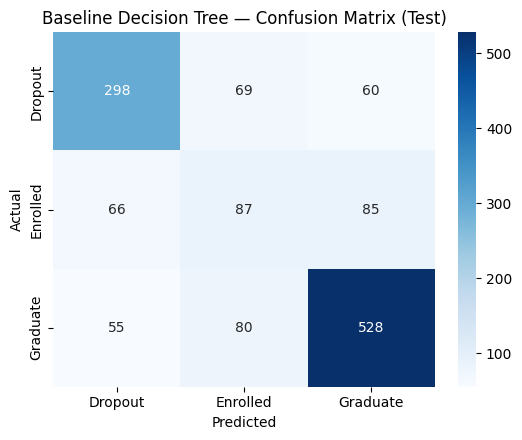

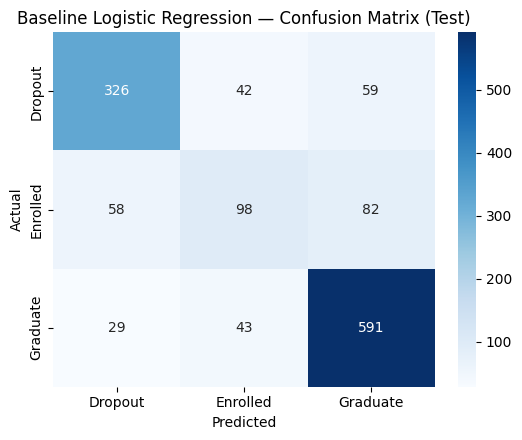

In [6]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion(y_test, y_pred_dt, 'Baseline Decision Tree — Confusion Matrix (Test)')
plot_confusion(y_test, y_pred_lr, 'Baseline Logistic Regression — Confusion Matrix (Test)')


## 3) ROC Curves + AUC (Multiclass OvR)

We plot one-vs-rest ROC curves per class and report AUC per class. We also report **macro** and **micro** AUC.


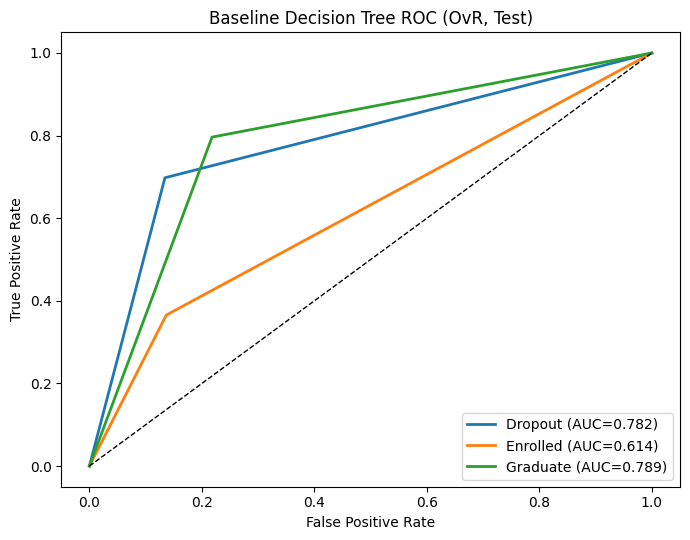

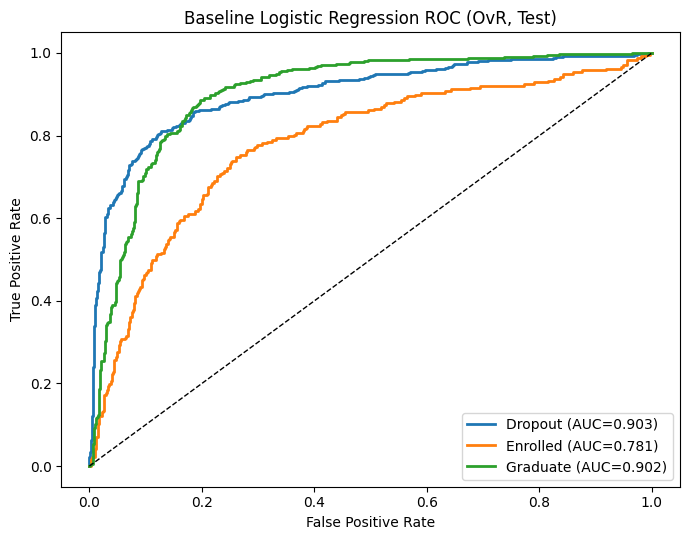

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DecisionTree,0.781799,0.614424,0.789167,0.765625,0.728463
LogReg,0.902661,0.781301,0.901900,0.890824,0.861954


In [7]:
def multiclass_roc_auc(model, X_eval, y_eval, class_names, title_prefix=""):
    """Multiclass OvR ROC/AUC.

    We assume `class_names[k]` corresponds to label `classes[k]` where
    `classes = np.sort(np.unique(y_eval))`. With a stratified split, all
    three classes are present in `y_test`, so indices align. If a class were
    missing from `y_eval`, remap labels/names before plotting.
    """
    classes = np.sort(np.unique(y_eval))
    y_bin = label_binarize(y_eval, classes=classes)
    proba = model.predict_proba(X_eval)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average AUC via sklearn
    roc_auc_macro = roc_auc_score(y_bin, proba, average="macro")

    plt.figure(figsize=(7, 5.5))
    for i in range(len(classes)):
        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})",
        )
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC (OvR, Test)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return {
        **{f"auc_{class_names[i]}": roc_auc[i] for i in range(len(classes))},
        "auc_micro": roc_auc["micro"],
        "auc_macro": roc_auc_macro,
    }


auc_dt_base = multiclass_roc_auc(
    dt_base, X_test, y_test, LABEL_NAMES, title_prefix="Baseline Decision Tree"
)
auc_lr_base = multiclass_roc_auc(
    lr_base, X_test, y_test, LABEL_NAMES, title_prefix="Baseline Logistic Regression"
)

auc_table = pd.DataFrame([auc_dt_base, auc_lr_base], index=["DecisionTree", "LogReg"])
display(auc_table)


## 4) Improve Models via Validation (two strategies)

We compare:

- **Strategy A (CV tuning):** `GridSearchCV` with `StratifiedKFold` on the **training split**.
- **Strategy B (Holdout validation):** split the training data into train/val, tune on val.

Finally, we evaluate tuned models on the fixed **test split**.


In [8]:
# Strategy A: GridSearchCV (CV) on TRAIN only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"],
}

lr_pipe = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)),
    ]
)
lr_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
    "lr__class_weight": [None, "balanced"],
}

dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

lr_cv = GridSearchCV(
    lr_pipe,
    lr_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

dt_cv.fit(X_train, y_train)
lr_cv.fit(X_train, y_train)

print("CV best params:")
print("  DT:", dt_cv.best_params_)
print("  LR:", lr_cv.best_params_)
print("\nCV best scores (f1_macro):")
print(f"  DT: {dt_cv.best_score_:.4f}")
print(f"  LR: {lr_cv.best_score_:.4f}")


CV best params:
  DT: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
  LR: {'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}

CV best scores (f1_macro):
  DT: 0.6490
  LR: 0.6954


In [9]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    met = metrics_summary(y_eval, y_pred)
    met['model'] = name
    return met


dt_cv_best = dt_cv.best_estimator_
lr_cv_best = lr_cv.best_estimator_

cv_metrics = pd.DataFrame([
    evaluate_model('DT_CV', dt_cv_best, X_test, y_test),
    evaluate_model('LR_CV', lr_cv_best, X_test, y_test),
]).set_index('model')

display(cv_metrics)


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_CV,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722
LR_CV,0.725151,0.692522,0.699715,0.688043,0.761179,0.725151,0.737734


In [10]:
# Strategy B: Holdout validation split from TRAIN only
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)


def holdout_tune(estimator, param_grid, X_tr_in, y_tr_in, X_val_in, y_val_in, X_full, y_full):
    # Pick hyperparameters by macro-F1 on validation; refit on full training data.
    best_score = -1.0
    best_params = None
    for params in ParameterGrid(param_grid):
        est = clone(estimator).set_params(**params)
        est.fit(X_tr_in, y_tr_in)
        pred = est.predict(X_val_in)
        score = f1_score(y_val_in, pred, average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_params = params
    final = clone(estimator).set_params(**best_params)
    final.fit(X_full, y_full)
    return best_score, final


dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"],
}

lr_pipe_tpl = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)),
    ]
)
lr_param_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
    "lr__class_weight": [None, "balanced"],
}

dt_holdout_score, dt_holdout_best = holdout_tune(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    X_tr,
    y_tr,
    X_val,
    y_val,
    X_train,
    y_train,
)
lr_holdout_score, lr_holdout_best = holdout_tune(
    lr_pipe_tpl,
    lr_param_grid,
    X_tr,
    y_tr,
    X_val,
    y_val,
    X_train,
    y_train,
)

print("Holdout best validation f1_macro:")
print(f"  DT: {dt_holdout_score:.4f}")
print(f"  LR: {lr_holdout_score:.4f}")

holdout_metrics = pd.DataFrame(
    [
        evaluate_model("DT_Holdout", dt_holdout_best, X_test, y_test),
        evaluate_model("LR_Holdout", lr_holdout_best, X_test, y_test),
    ]
).set_index("model")

display(holdout_metrics)


Holdout best validation f1_macro:
  DT: 0.6636
  LR: 0.7197


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_Holdout,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722
LR_Holdout,0.727410,0.694984,0.702121,0.690495,0.762812,0.727410,0.739716


In [11]:
# Compare all models on the FIXED test split
compare = pd.concat(
    [
        baseline_table.assign(strategy='Baseline'),
        cv_metrics.assign(strategy='CV'),
        holdout_metrics.assign(strategy='Holdout'),
    ],
    axis=0,
)

display(compare.sort_values('f1_macro', ascending=False))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,strategy
LogReg,0.764307,0.710747,0.688878,0.696353,0.752858,0.764307,0.756027,Baseline
LR_Holdout,0.727410,0.694984,0.702121,0.690495,0.762812,0.727410,0.739716,Holdout
LR_CV,0.725151,0.692522,0.699715,0.688043,0.761179,0.725151,0.737734,CV
DT_CV,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722,CV
DT_Holdout,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722,Holdout
DecisionTree,0.687500,0.621469,0.619940,0.620666,0.686432,0.687500,0.686922,Baseline


## 5) ROC/AUC for Tuned Models (optional, recommended)

Plot ROC curves and report AUC for the best CV-tuned and holdout-tuned models.


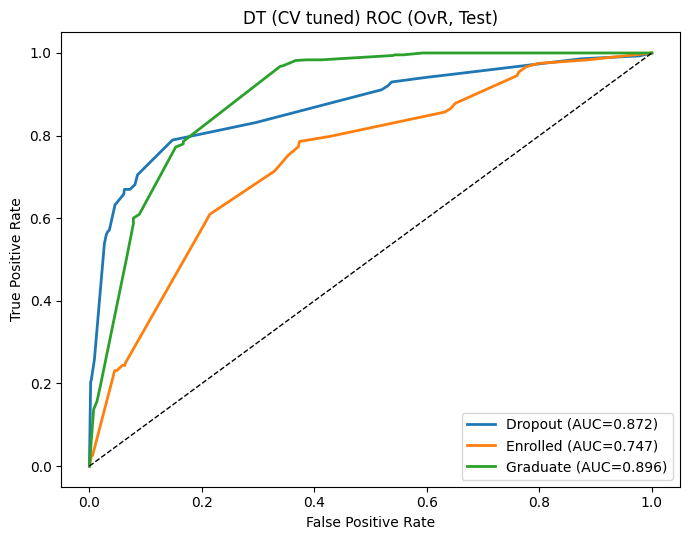

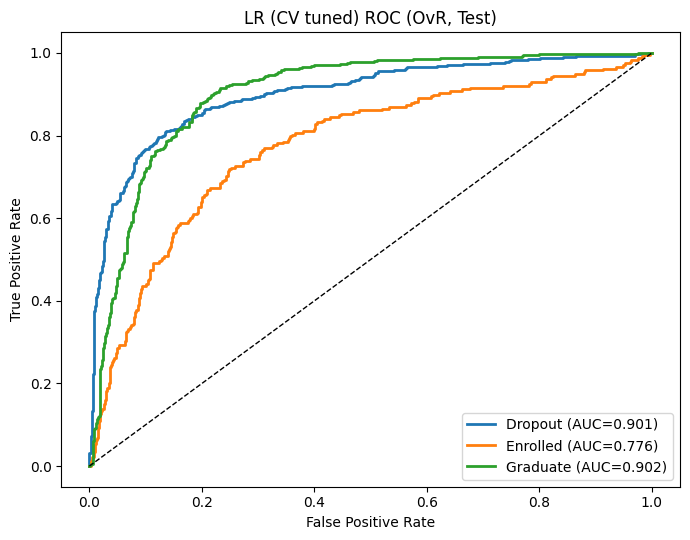

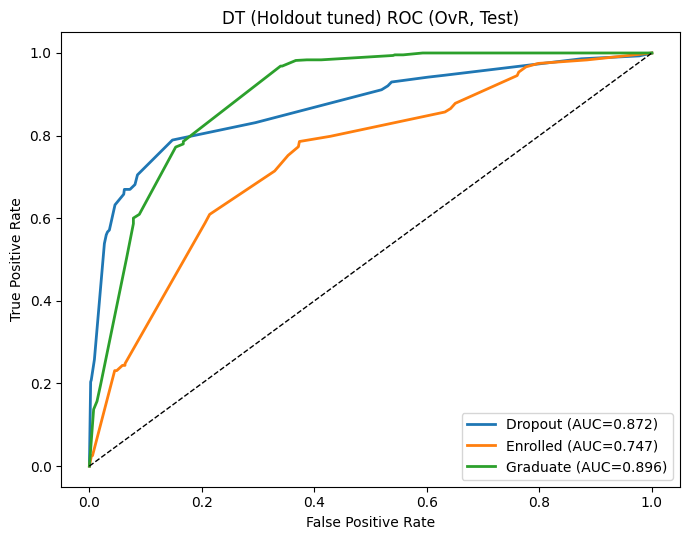

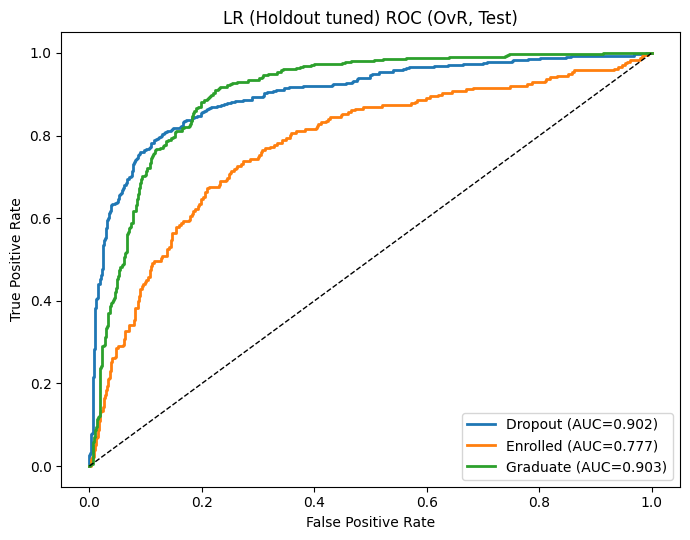

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DT_CV,0.871588,0.747130,0.895591,0.857075,0.838103
LR_CV,0.901413,0.775576,0.901868,0.873291,0.859619
DT_Holdout,0.871588,0.747130,0.895591,0.857075,0.838103
LR_Holdout,0.901577,0.776991,0.903267,0.874506,0.860612


In [12]:
auc_dt_cv = multiclass_roc_auc(dt_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (CV tuned)')
auc_lr_cv = multiclass_roc_auc(lr_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (CV tuned)')

auc_dt_hold = multiclass_roc_auc(dt_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (Holdout tuned)')
auc_lr_hold = multiclass_roc_auc(lr_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (Holdout tuned)')

auc_tuned = pd.DataFrame(
    [auc_dt_cv, auc_lr_cv, auc_dt_hold, auc_lr_hold],
    index=['DT_CV', 'LR_CV', 'DT_Holdout', 'LR_Holdout'],
)
display(auc_tuned)


## 6) Interpretation of metrics (with the measured numbers)

From the **baseline** evaluation on the fixed Part 4 test split:

- **Logistic Regression** achieves **accuracy = 0.7643** and **macro-F1 = 0.6964** (weighted-F1 = 0.7560), while the **Decision Tree** achieves **accuracy = 0.6875** and **macro-F1 = 0.6207** (weighted-F1 = 0.6869). LR generalizes substantially better on class-balanced performance.

From the **ROC/AUC** tables:

- LR has consistently higher **macro AUC** than DT. Baseline: LR **0.8620** vs DT **0.7285**. After tuning: LR_CV **0.8596**, LR_Holdout **0.8606** vs DT_CV **0.8381**, DT_Holdout **0.8381** — LR's predicted probabilities rank the true class more reliably.
- The hardest class is **Enrolled**: its AUC is the lowest across every model (baseline DT **0.6144**, baseline LR **0.7813**; tuned DT **0.7471**, tuned LR **~0.776**), and confusion matrices show Enrolled most often predicted as Graduate.

**Overfitting:** the baseline DT trails LR sharply on test AUC, and tuning (`max_depth=5`, `class_weight='balanced'`) lifts its macro AUC from **0.7285** to **0.8381** — a clear sign the unconstrained tree was memorizing the training set.

---

## 7) Description & interpretation of validation results

### Validation scores (training-only)

- **CV (GridSearchCV) best `f1_macro`**:
  - Decision Tree: **0.6490**
  - Logistic Regression: **0.6954**
- **Holdout validation best `f1_macro`**:
  - Decision Tree: **0.6636**
  - Logistic Regression: **0.7197**

### Test-set impact (fixed Part 4 test split)

Using the combined comparison table on the fixed test split:

- **Logistic Regression** changes only slightly after tuning:
  - Baseline macro-F1 **0.6964** (accuracy **0.7643**)
  - CV macro-F1 **0.6880** (accuracy **0.7252**)
  - Holdout macro-F1 **0.6905** (accuracy **0.7274**)
- **Decision Tree** improves on class-balanced metrics after tuning:
  - Baseline macro-F1 **0.6207**
  - CV macro-F1 **0.6304**
  - Holdout macro-F1 **0.6304** (same best params as CV)

Interpretation: holdout yields higher validation scores than CV, but on the fixed test split the CV-vs-holdout difference is small. The main tuning gain for DT is in **AUC** (probability ranking lifts from 0.7285 to 0.8381 macro), while LR's AUC stays roughly constant and its macro-F1/accuracy move only modestly (the baseline LR is already well-regularized).

---

## 8) Further discussion (100–200 words)

On the fixed Part 4 test split, Logistic Regression outperforms the Decision Tree on class-balanced metrics. Baseline LR reaches macro-F1 ≈ 0.70 and macro AUC ≈ 0.86, while the unconstrained DT sits at macro-F1 ≈ 0.62 and macro AUC ≈ 0.73 — consistent with higher variance and overfitting risk in the tree. ROC/AUC analysis confirms the ordering, and the *Enrolled* class has the lowest one-vs-rest AUC across every model, matching the confusion-matrix pattern where Enrolled is most often predicted as Graduate.

We improved models via validation without using the test set for tuning. CV (GridSearchCV) and holdout train/val tuning select similar LR settings (C=1, class_weight='balanced'), and test performance barely changes, suggesting LR is already near a good optimum under this feature representation. For the Decision Tree, tuning (depth cap plus class weighting) lifts macro AUC from 0.73 to 0.84 and narrows the gap to LR. Model choice is made on held-out test macro-F1/AUC, with the test set untouched during validation.